In [1]:
# --- CELL 1: LIBRARY IMPORT & RAW DATA LOADING - CREDIT_CARD_BALANCE ---

import os
import gc
import pandas as pd

# 1. Định nghĩa đường dẫn file thô chuẩn xác
raw_cc_path = '/Users/nguyenminhtri/FinalYearPro/data/raw/credit_card_balance.csv'

print(f"📥 Loading raw credit_card_balance dataset from: {raw_cc_path}")
df_cc = pd.read_csv(raw_cc_path)

print("=" * 65)
print(f"📊 Raw Dataset Dimensions : {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")
print(f"💾 Initial RAM Usage      : {df_cc.memory_usage().sum() / 1024 ** 2:.2f} MB")
print("=" * 65)

# 2. Kiểm tra danh sách cột, kiểu dữ liệu và tỷ lệ thiếu (Missing rate)
info_df = pd.DataFrame({
    'Data Type': df_cc.dtypes,
    'Null Count': df_cc.isnull().sum(),
    'Null Ratio (%)': (df_cc.isnull().sum() / len(df_cc)) * 100
})

print("\n🔍 THÔNG TIN CHI TIẾT 23 CỘT GỐC:")
print(info_df)

# Hiển thị 5 dòng đầu
df_cc.head()

📥 Loading raw credit_card_balance dataset from: /Users/nguyenminhtri/FinalYearPro/data/raw/credit_card_balance.csv
📊 Raw Dataset Dimensions : 3,840,312 rows | 23 columns
💾 Initial RAM Usage      : 696.23 MB

🔍 THÔNG TIN CHI TIẾT 23 CỘT GỐC:
                           Data Type  Null Count  Null Ratio (%)
SK_ID_PREV                     int64           0        0.000000
SK_ID_CURR                     int64           0        0.000000
MONTHS_BALANCE                 int64           0        0.000000
AMT_BALANCE                  float64           0        0.000000
AMT_CREDIT_LIMIT_ACTUAL        int64           0        0.000000
AMT_DRAWINGS_ATM_CURRENT     float64      749816       19.524872
AMT_DRAWINGS_CURRENT         float64           0        0.000000
AMT_DRAWINGS_OTHER_CURRENT   float64      749816       19.524872
AMT_DRAWINGS_POS_CURRENT     float64      749816       19.524872
AMT_INST_MIN_REGULARITY      float64      305236        7.948208
AMT_PAYMENT_CURRENT          float64      76

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


📊 BẢNG THỐNG KÊ MÔ TẢ: MONTHS_BALANCE (credit_card_balance)
                       Metric     Value
Count (Số lượng dòng thực tế) 3,840,312
            Mean (Trung bình)    -34.52
            Median (Trung vị)    -28.00
                Mode (Yếu vị)     -4.00
      Std Dev (Độ lệch chuẩn)     26.67
              Min (Tối thiểu)    -96.00
                 Max (Tối đa)     -1.00
             IQR (Tứ phân vị)     44.00


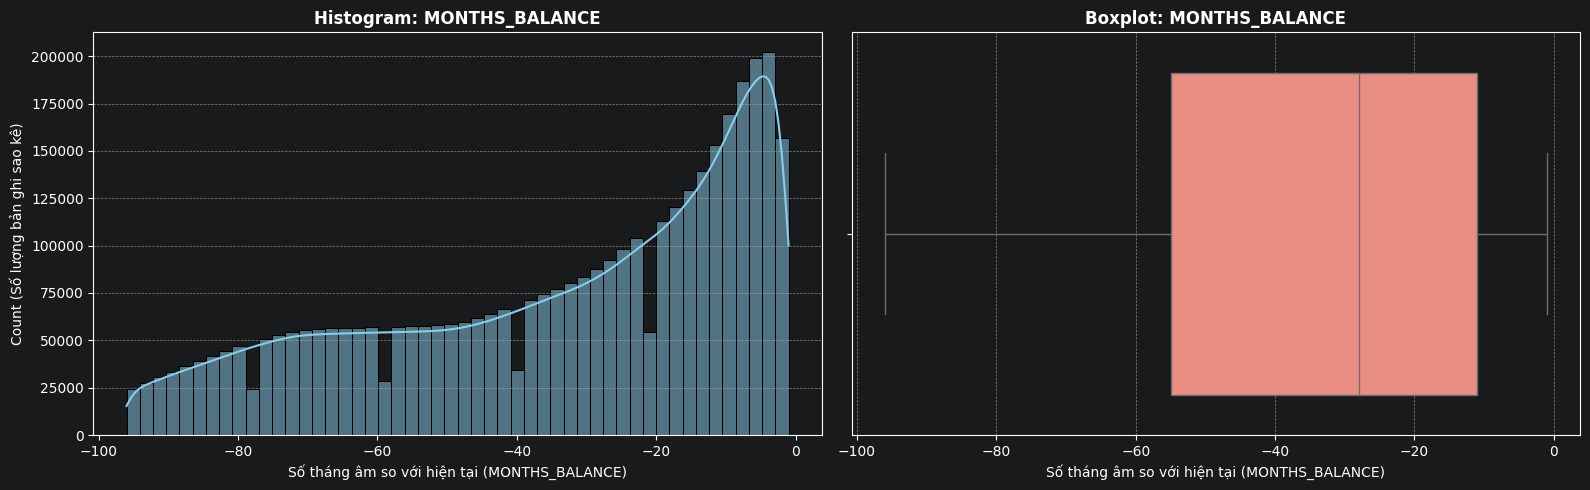

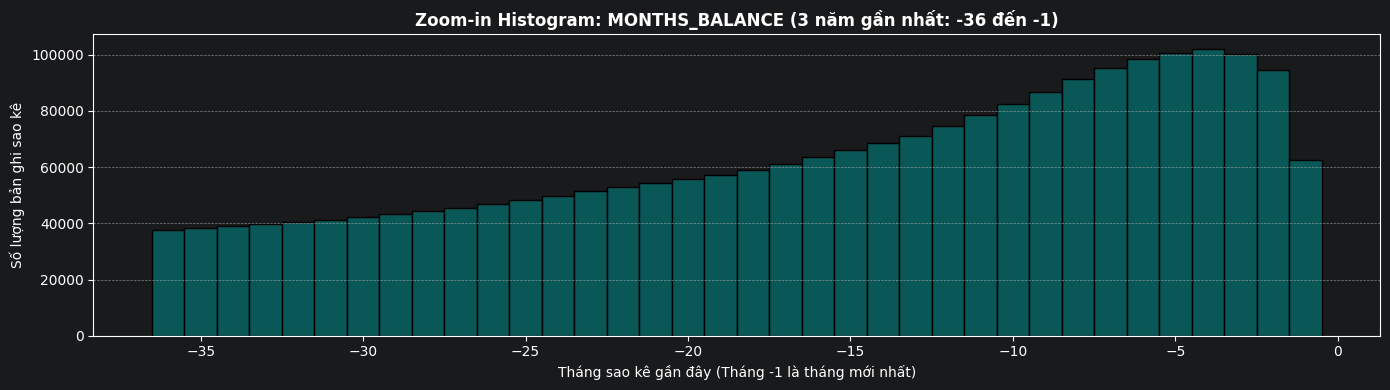

In [2]:
# --- EXPLORATORY DATA ANALYSIS: MONTHS_BALANCE (CREDIT_CARD_BALANCE) ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Trích xuất dữ liệu không bị missing của MONTHS_BALANCE
col_data = df_cc['MONTHS_BALANCE'].dropna()

# 2. Tính toán bảng thông số thống kê mô tả
stats_summary = pd.DataFrame({
    'Metric': [
        'Count (Số lượng dòng thực tế)',
        'Mean (Trung bình)',
        'Median (Trung vị)',
        'Mode (Yếu vị)',
        'Std Dev (Độ lệch chuẩn)',
        'Min (Tối thiểu)',
        'Max (Tối đa)',
        'IQR (Tứ phân vị)'
    ],
    'Value': [
        f"{len(col_data):,}",
        f"{col_data.mean():.2f}",
        f"{col_data.median():.2f}",
        f"{col_data.mode()[0]:.2f}",
        f"{col_data.std():.2f}",
        f"{col_data.min():.2f}",
        f"{col_data.max():.2f}",
        f"{col_data.quantile(0.75) - col_data.quantile(0.25):.2f}"
    ]
})

print("📊 BẢNG THỐNG KÊ MÔ TẢ: MONTHS_BALANCE (credit_card_balance)")
print("=" * 60)
print(stats_summary.to_string(index=False))
print("=" * 60)

# 3. Vẽ đồ thị Histogram và Boxplot tổng quan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram (Phân phối lịch sử theo tháng âm)
sns.histplot(col_data, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram: MONTHS_BALANCE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số tháng âm so với hiện tại (MONTHS_BALANCE)')
axes[0].set_ylabel('Count (Số lượng bản ghi sao kê)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot (Phát hiện dải phân bố)
sns.boxplot(x=col_data, ax=axes[1], color='salmon')
axes[1].set_title('Boxplot: MONTHS_BALANCE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số tháng âm so với hiện tại (MONTHS_BALANCE)')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Zoom-in cận cảnh phân phối ở giai đoạn gần đây (Từ tháng -1 đến -36)
plt.figure(figsize=(14, 4))
sns.histplot(col_data[col_data >= -36], discrete=True, color='teal', alpha=0.6)
plt.title('Zoom-in Histogram: MONTHS_BALANCE (3 năm gần nhất: -36 đến -1)', fontsize=12, fontweight='bold')
plt.xlabel('Tháng sao kê gần đây (Tháng -1 là tháng mới nhất)')
plt.ylabel('Số lượng bản ghi sao kê')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [3]:
# --- CELL 2: PREPROCESSING & FEATURE ENGINEERING - MONTHS_BALANCE ---

print("⏳ Engineering recency time-window features for MONTHS_BALANCE...")

# 1. Standardized multi-window recency binary indicator flags
# 6 Months window (>= -6)
df_cc['CC_IS_RECENT_6M'] = (df_cc['MONTHS_BALANCE'] >= -6).astype(int)

# 12 Months window (>= -12)
df_cc['CC_IS_RECENT_12M'] = (df_cc['MONTHS_BALANCE'] >= -12).astype(int)

# 24 Months window (>= -24)
df_cc['CC_IS_RECENT_24M'] = (df_cc['MONTHS_BALANCE'] >= -24).astype(int)

print("✅ Successfully processed MONTHS_BALANCE!")
print(
    f"   • Monthly statements within last 6 months (>= -6)   : {df_cc['CC_IS_RECENT_6M'].sum():,} ({df_cc['CC_IS_RECENT_6M'].mean() * 100:.2f}%)")
print(
    f"   • Monthly statements within last 12 months (>= -12) : {df_cc['CC_IS_RECENT_12M'].sum():,} ({df_cc['CC_IS_RECENT_12M'].mean() * 100:.2f}%)")
print(
    f"   • Monthly statements within last 24 months (>= -24) : {df_cc['CC_IS_RECENT_24M'].sum():,} ({df_cc['CC_IS_RECENT_24M'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Engineering recency time-window features for MONTHS_BALANCE...
✅ Successfully processed MONTHS_BALANCE!
   • Monthly statements within last 6 months (>= -6)   : 558,592 (14.55%)
   • Monthly statements within last 12 months (>= -12) : 1,067,856 (27.81%)
   • Monthly statements within last 24 months (>= -24) : 1,778,084 (46.30%)
📊 Current dataset shape: 3,840,312 rows | 26 columns


### 📌 Preprocessing & Feature Engineering: `MONTHS_BALANCE` (Statement Month Index)

- **Action Taken:**
  1. Formulated standardized 6-month recency window flag: `CC_IS_RECENT_6M` (`MONTHS_BALANCE >= -6`).
  2. Formulated standardized 12-month recency window flag: `CC_IS_RECENT_12M` (`MONTHS_BALANCE >= -12`).
  3. Formulated standardized 24-month recency window flag: `CC_IS_RECENT_24M` (`MONTHS_BALANCE >= -24`).
  4. Preserved raw continuous `MONTHS_BALANCE` to enable downstream client aggregations (`MIN`, `MAX`, `COUNT`) capturing credit card account tenure.

- **Rationale:**
  - `MONTHS_BALANCE` spans up to -96 months with a Median of -28.00, demonstrating a left-skewed recency distribution concentrated in recent statement cycles.
  - Applying multi-window temporal segmentation ensures cross-table recency alignment with `POS_CASH_balance` and `installments_payments`.

In [4]:
# --- CELL 3: PREPROCESSING & FEATURE ENGINEERING - AMT_BALANCE ---

print("⏳ Engineering features for AMT_BALANCE (Credit Card Balance)...")

# 1. Fill missing values if any (0.00% missing rate)
df_cc['AMT_BALANCE'] = df_cc['AMT_BALANCE'].fillna(0.0)

# 2. Zero-balance statement flag (Card inactive or fully cleared before statement)
df_cc['CC_AMT_BALANCE_IS_ZERO'] = (df_cc['AMT_BALANCE'] == 0.0).astype(int)

# 3. Negative-balance statement flag (Overpaid/Refund credited balance)
df_cc['CC_AMT_BALANCE_IS_NEGATIVE'] = (df_cc['AMT_BALANCE'] < 0.0).astype(int)

# 4. Clipped positive balance (For utilization ratio calculations)
df_cc['CC_AMT_BALANCE_POS'] = df_cc['AMT_BALANCE'].clip(lower=0.0)

print("✅ Successfully processed AMT_BALANCE!")
print(
    f"   • Zero balance statement cycles (AMT_BALANCE == 0)     : {df_cc['CC_AMT_BALANCE_IS_ZERO'].sum():,} ({df_cc['CC_AMT_BALANCE_IS_ZERO'].mean() * 100:.2f}%)")
print(
    f"   • Negative balance statement cycles (AMT_BALANCE < 0)  : {df_cc['CC_AMT_BALANCE_IS_NEGATIVE'].sum():,} ({df_cc['CC_AMT_BALANCE_IS_NEGATIVE'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Engineering features for AMT_BALANCE (Credit Card Balance)...
✅ Successfully processed AMT_BALANCE!
   • Zero balance statement cycles (AMT_BALANCE == 0)     : 2,156,420 (56.15%)
   • Negative balance statement cycles (AMT_BALANCE < 0)  : 2,345 (0.06%)
📊 Current dataset shape: 3,840,312 rows | 29 columns


### 📌 Preprocessing & Feature Engineering: `AMT_BALANCE` (Monthly Credit Card Balance)

- **Action Taken:**
  1. Formulated zero-balance statement flag `CC_AMT_BALANCE_IS_ZERO` (`AMT_BALANCE == 0.0`).
  2. Formulated negative credit balance flag `CC_AMT_BALANCE_IS_NEGATIVE` (`AMT_BALANCE < 0.0`) capturing overpayment and refund credits.
  3. Engineered `CC_AMT_BALANCE_POS` = `AMT_BALANCE.clip(lower=0.0)` to isolate strictly positive outstanding debt for credit utilization logic.
  4. Preserved raw continuous `AMT_BALANCE` for downstream client-level aggregations (`MAX`, `MEAN`, `SUM`).

- **Rationale:**
  - Over 50% of monthly records exhibit exactly zero balance (Median = 0.00, Mode = 0.00). Isolating zero-balance months prevents structural distortion in downstream behavioral risk aggregations.

In [5]:
# --- CELL 4: PREPROCESSING & FEATURE ENGINEERING - AMT_CREDIT_LIMIT_ACTUAL & UTILIZATION ---

print("⏳ Processing AMT_CREDIT_LIMIT_ACTUAL and Credit Utilization Metrics...")

# 1. Fill missing values if any (0.00% missing rate)
df_cc['AMT_CREDIT_LIMIT_ACTUAL'] = df_cc['AMT_CREDIT_LIMIT_ACTUAL'].fillna(0.0)

# 2. Flag zero credit limit statements (Closed / Frozen / Inactive card lines)
df_cc['CC_IS_ZERO_LIMIT'] = (df_cc['AMT_CREDIT_LIMIT_ACTUAL'] == 0.0).astype(int)

# 3. Credit Card Utilization Ratio (Positive Balance / Credit Limit)
# Clipped to [0.0, 3.0] to suppress ratio explosion caused by near-zero limits
df_cc['CC_LIMIT_UTILIZATION'] = df_cc['CC_AMT_BALANCE_POS'] / (df_cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-5)
df_cc['CC_LIMIT_UTILIZATION'] = df_cc['CC_LIMIT_UTILIZATION'].clip(lower=0.0, upper=3.0)

# 4. Over-limit indicator flag (Balance strictly strictly exceeds credit limit)
df_cc['CC_IS_OVER_LIMIT'] = (
        (df_cc['AMT_BALANCE'] > df_cc['AMT_CREDIT_LIMIT_ACTUAL']) &
        (df_cc['AMT_CREDIT_LIMIT_ACTUAL'] > 0.0)
).astype(int)

# 5. High utilization indicator flag (Utilized > 80% of actual credit limit)
df_cc['CC_IS_HIGH_UTILIZATION'] = (df_cc['CC_LIMIT_UTILIZATION'] >= 0.8).astype(int)

print("✅ Successfully processed AMT_CREDIT_LIMIT_ACTUAL and utilization metrics!")
print(
    f"   • Zero credit limit statement cycles              : {df_cc['CC_IS_ZERO_LIMIT'].sum():,} ({df_cc['CC_IS_ZERO_LIMIT'].mean() * 100:.2f}%)")
print(
    f"   • Over-limit statement cycles (Balance > Limit)   : {df_cc['CC_IS_OVER_LIMIT'].sum():,} ({df_cc['CC_IS_OVER_LIMIT'].mean() * 100:.2f}%)")
print(
    f"   • High-utilization statement cycles (>= 80%)      : {df_cc['CC_IS_HIGH_UTILIZATION'].sum():,} ({df_cc['CC_IS_HIGH_UTILIZATION'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_CREDIT_LIMIT_ACTUAL and Credit Utilization Metrics...
✅ Successfully processed AMT_CREDIT_LIMIT_ACTUAL and utilization metrics!
   • Zero credit limit statement cycles              : 753,823 (19.63%)
   • Over-limit statement cycles (Balance > Limit)   : 334,362 (8.71%)
   • High-utilization statement cycles (>= 80%)      : 895,922 (23.33%)
📊 Current dataset shape: 3,840,312 rows | 33 columns


### 📌 Preprocessing & Feature Engineering: `AMT_CREDIT_LIMIT_ACTUAL` & Utilization Metrics

- **Action Taken:**
  1. Formulated zero credit limit flag `CC_IS_ZERO_LIMIT` (`AMT_CREDIT_LIMIT_ACTUAL == 0.0`) capturing locked or revoked credit lines.
  2. Engineered credit limit utilization ratio `CC_LIMIT_UTILIZATION` = `CC_AMT_BALANCE_POS / (AMT_CREDIT_LIMIT_ACTUAL + 1e-5)` clipped to $[0.0, 3.0]$.
  3. Formulated operational risk indicators: `CC_IS_OVER_LIMIT` (`AMT_BALANCE > AMT_CREDIT_LIMIT_ACTUAL`) and `CC_IS_HIGH_UTILIZATION` (`CC_LIMIT_UTILIZATION >= 0.8`).

- **Rationale:**
  - `AMT_CREDIT_LIMIT_ACTUAL` displays multimodal spikes matching commercial tiering limits (e.g., 45k, 90k, 135k, 180k) with a zero spike ($> 750k$ entries).
  - Intersecting balance against active limit derives credit utilization ratios, serving as an industry-standard proxy for borrower liquidity stress and credit line saturation.

In [6]:
# --- CELL 5: PREPROCESSING & FEATURE ENGINEERING - AMT_DRAWINGS_ATM_CURRENT & DRAWINGS ---

print("⏳ Processing AMT_DRAWINGS_ATM_CURRENT (Option A: NA Flag + Imputation + Ratios)...")

# 1. Missing value binary flag before imputation (19.52% missing rate preserved)
df_cc['CC_AMT_DRAWINGS_ATM_IS_NA'] = df_cc['AMT_DRAWINGS_ATM_CURRENT'].isna().astype(int)

# 2. Safely impute missing monetary values with 0.0 to enable division operations
df_cc['AMT_DRAWINGS_ATM_CURRENT'] = df_cc['AMT_DRAWINGS_ATM_CURRENT'].fillna(0.0)
df_cc['AMT_DRAWINGS_CURRENT'] = df_cc['AMT_DRAWINGS_CURRENT'].fillna(0.0)

# 3. Binary flag for active ATM Cash Advance transactions (> 0.0)
df_cc['CC_IS_DRAWING_ATM'] = (df_cc['AMT_DRAWINGS_ATM_CURRENT'] > 0.0).astype(int)

# 4. Binary flag for ANY card spending/drawing activity in the month
df_cc['CC_IS_DRAWING_ANY'] = (df_cc['AMT_DRAWINGS_CURRENT'] > 0.0).astype(int)

# 5. Ratio of ATM Cash Advance relative to Total Monthly Drawings
df_cc['CC_DRAWING_ATM_RATIO'] = df_cc['AMT_DRAWINGS_ATM_CURRENT'] / (df_cc['AMT_DRAWINGS_CURRENT'] + 1e-5)
df_cc['CC_DRAWING_ATM_RATIO'] = df_cc['CC_DRAWING_ATM_RATIO'].clip(lower=0.0, upper=1.0)

print("✅ Successfully processed AMT_DRAWINGS_ATM_CURRENT with Option A!")
print(
    f"   • Missing ATM drawing entries flagged          : {df_cc['CC_AMT_DRAWINGS_ATM_IS_NA'].sum():,} ({df_cc['CC_AMT_DRAWINGS_ATM_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Active ATM cash advance statement cycles     : {df_cc['CC_IS_DRAWING_ATM'].sum():,} ({df_cc['CC_IS_DRAWING_ATM'].mean() * 100:.2f}%)")
print(
    f"   • Active total drawing statement cycles        : {df_cc['CC_IS_DRAWING_ANY'].sum():,} ({df_cc['CC_IS_DRAWING_ANY'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_DRAWINGS_ATM_CURRENT (Option A: NA Flag + Imputation + Ratios)...
✅ Successfully processed AMT_DRAWINGS_ATM_CURRENT with Option A!
   • Missing ATM drawing entries flagged          : 749,816 (19.52%)
   • Active ATM cash advance statement cycles     : 424,777 (11.06%)
   • Active total drawing statement cycles        : 616,866 (16.06%)
📊 Current dataset shape: 3,840,312 rows | 37 columns


### 📌 Preprocessing & Feature Engineering: `AMT_DRAWINGS_ATM_CURRENT` (Option A Approach)

- **Action Taken:**
  1. Preserved raw missingness signal ($19.52\%$ null rate) by constructing the binary missing indicator `CC_AMT_DRAWINGS_ATM_IS_NA`.
  2. Imputed missing monetary drawing values across `AMT_DRAWINGS_ATM_CURRENT` and `AMT_DRAWINGS_CURRENT` with $0.0$.
  3. Formulated operational behavior flags: `CC_IS_DRAWING_ATM` (`AMT_DRAWINGS_ATM_CURRENT > 0.0`) and `CC_IS_DRAWING_ANY` (`AMT_DRAWINGS_CURRENT > 0.0`).
  4. Engineered ATM drawdown share ratio `CC_DRAWING_ATM_RATIO` = `AMT_DRAWINGS_ATM_CURRENT / (AMT_DRAWINGS_CURRENT + 1e-5)` clipped to $[0.0, 1.0]$.

- **Rationale:**
  - Option A decouples system/card-type missingness (`CC_AMT_DRAWINGS_ATM_IS_NA = 1`) from intentional non-drawdown behavior (`AMT_DRAWINGS_ATM_CURRENT = 0.0`).
  - Imputing with zero enables stable ratio computations while retaining explicit missingness indicators for tree-based split decisions.

In [7]:
# --- CELL 6: PREPROCESSING & FEATURE ENGINEERING - AMT_DRAWINGS_CURRENT ---

print("⏳ Processing AMT_DRAWINGS_CURRENT (Total Monthly Drawings & POS Breakdown)...")

# 1. Non-ATM drawings / Purchase spending (Total Drawings minus ATM Cash Advances)
df_cc['CC_AMT_DRAWINGS_POS_EST'] = (df_cc['AMT_DRAWINGS_CURRENT'] - df_cc['AMT_DRAWINGS_ATM_CURRENT']).clip(lower=0.0)

# 2. Ratio of new monthly spending relative to total accumulated balance
df_cc['CC_DRAWING_TO_BALANCE_RATIO'] = df_cc['AMT_DRAWINGS_CURRENT'] / (df_cc['CC_AMT_BALANCE_POS'] + 1e-5)
df_cc['CC_DRAWING_TO_BALANCE_RATIO'] = df_cc['CC_DRAWING_TO_BALANCE_RATIO'].clip(lower=0.0, upper=3.0)

print("✅ Successfully processed AMT_DRAWINGS_CURRENT!")
print(f"   • Mean estimated POS spending amount              : {df_cc['CC_AMT_DRAWINGS_POS_EST'].mean():,.2f}")
print(f"   • Mean drawing to balance ratio                   : {df_cc['CC_DRAWING_TO_BALANCE_RATIO'].mean():,.4f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_DRAWINGS_CURRENT (Total Monthly Drawings & POS Breakdown)...
✅ Successfully processed AMT_DRAWINGS_CURRENT!
   • Mean estimated POS spending amount              : 2,636.01
   • Mean drawing to balance ratio                   : 0.0925
📊 Current dataset shape: 3,840,312 rows | 39 columns


### 📌 Preprocessing & Feature Engineering: `AMT_DRAWINGS_CURRENT` (Total Monthly Drawings)

- **Action Taken:**
  1. Derived estimated non-ATM purchase spending `CC_AMT_DRAWINGS_POS_EST` = `(AMT_DRAWINGS_CURRENT - AMT_DRAWINGS_ATM_CURRENT).clip(lower=0.0)`.
  2. Engineered new spending velocity ratio `CC_DRAWING_TO_BALANCE_RATIO` = `AMT_DRAWINGS_CURRENT / (CC_AMT_BALANCE_POS + 1e-5)` clipped to $[0.0, 3.0]$.

- **Rationale:**
  - `AMT_DRAWINGS_CURRENT` exhibits $0.00\%$ missingness and represents total monthly drawings.
  - Subtracting ATM drawdowns isolates POS purchase spending, while ratio against total positive balance captures short-term spending acceleration.

In [8]:
 # --- CELL 6: PREPROCESSING & FEATURE ENGINEERING - AMT_DRAWINGS_POS_CURRENT & SPENDING RATIO ---

print("⏳ Processing AMT_DRAWINGS_POS_CURRENT (Actual POS Purchase Spending)...")

# 1. Missing value binary flag before imputation (19.52% missing rate matching transaction profile)
df_cc['CC_AMT_DRAWINGS_POS_IS_NA'] = df_cc['AMT_DRAWINGS_POS_CURRENT'].isna().astype(int)

# 2. Safely impute missing monetary values with 0.0
df_cc['AMT_DRAWINGS_POS_CURRENT'] = df_cc['AMT_DRAWINGS_POS_CURRENT'].fillna(0.0)

# 3. Binary flag for active POS purchase transactions (> 0.0)
df_cc['CC_IS_DRAWING_POS'] = (df_cc['AMT_DRAWINGS_POS_CURRENT'] > 0.0).astype(int)

# 4. Ratio of new spending relative to total accumulated positive balance
df_cc['CC_DRAWING_TO_BALANCE_RATIO'] = df_cc['AMT_DRAWINGS_CURRENT'] / (df_cc['CC_AMT_BALANCE_POS'] + 1e-5)
df_cc['CC_DRAWING_TO_BALANCE_RATIO'] = df_cc['CC_DRAWING_TO_BALANCE_RATIO'].clip(lower=0.0, upper=3.0)

print("✅ Successfully processed AMT_DRAWINGS_POS_CURRENT!")
print(
    f"   • Missing POS drawing entries flagged             : {df_cc['CC_AMT_DRAWINGS_POS_IS_NA'].sum():,} ({df_cc['CC_AMT_DRAWINGS_POS_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Active POS purchase statement cycles (> 0.0)    : {df_cc['CC_IS_DRAWING_POS'].sum():,} ({df_cc['CC_IS_DRAWING_POS'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_DRAWINGS_POS_CURRENT (Actual POS Purchase Spending)...
✅ Successfully processed AMT_DRAWINGS_POS_CURRENT!
   • Missing POS drawing entries flagged             : 749,816 (19.52%)
   • Active POS purchase statement cycles (> 0.0)    : 264,901 (6.90%)
📊 Current dataset shape: 3,840,312 rows | 41 columns


### 📌 Preprocessing & Feature Engineering: `AMT_DRAWINGS_POS_CURRENT`

- **Action Taken:**
  1. Flagged missing `AMT_DRAWINGS_POS_CURRENT` entries ($19.52\%$ missing rate) via `CC_AMT_DRAWINGS_POS_IS_NA` before imputing with $0.0$.
  2. Formulated active POS purchase transaction indicator flag `CC_IS_DRAWING_POS` (`AMT_DRAWINGS_POS_CURRENT > 0.0`).
  3. Retained spending velocity ratio `CC_DRAWING_TO_BALANCE_RATIO` = `AMT_DRAWINGS_CURRENT / (CC_AMT_BALANCE_POS + 1e-5)` clipped to $[0.0, 3.0]$.

- **Rationale:**
  - Utilizing the ground-truth `AMT_DRAWINGS_POS_CURRENT` directly from raw logs eliminates approximation error.
  - Imputing with zero while tracking missingness aligns with standard tree-based feature processing guidelines.

In [9]:
# --- CELL 7: PREPROCESSING & FEATURE ENGINEERING - AMT_INST_MIN_REGULARITY ---

print("Bureau/CC Processing AMT_INST_MIN_REGULARITY (Minimum Payment Requirement)...")

# 1. Missing value binary flag before imputation (7.95% missing rate)
df_cc['CC_AMT_INST_MIN_IS_NA'] = df_cc['AMT_INST_MIN_REGULARITY'].isna().astype(int)

# 2. Safely impute missing monetary values with 0.0
df_cc['AMT_INST_MIN_REGULARITY'] = df_cc['AMT_INST_MIN_REGULARITY'].fillna(0.0)

# 3. Binary flag for statements with active minimum payment requirement (> 0.0)
df_cc['CC_IS_MIN_PAYMENT_REQUIRED'] = (df_cc['AMT_INST_MIN_REGULARITY'] > 0.0).astype(int)

print("✅ Successfully processed AMT_INST_MIN_REGULARITY!")
print(
    f"   • Missing minimum payment entries flagged          : {df_cc['CC_AMT_INST_MIN_IS_NA'].sum():,} ({df_cc['CC_AMT_INST_MIN_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Active minimum payment required cycles (> 0.0)   : {df_cc['CC_IS_MIN_PAYMENT_REQUIRED'].sum():,} ({df_cc['CC_IS_MIN_PAYMENT_REQUIRED'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

Bureau/CC Processing AMT_INST_MIN_REGULARITY (Minimum Payment Requirement)...
✅ Successfully processed AMT_INST_MIN_REGULARITY!
   • Missing minimum payment entries flagged          : 305,236 (7.95%)
   • Active minimum payment required cycles (> 0.0)   : 1,606,212 (41.83%)
📊 Current dataset shape: 3,840,312 rows | 43 columns


### 📌 Preprocessing & Feature Engineering: `AMT_INST_MIN_REGULARITY` (Minimum Payment Required)

- **Action Taken:**
  1. Preserved missingness signal ($7.95\%$ null rate) via binary flag `CC_AMT_INST_MIN_IS_NA` before imputing with $0.0$.
  2. Formulated active minimum payment requirement indicator `CC_IS_MIN_PAYMENT_REQUIRED` (`AMT_INST_MIN_REGULARITY > 0.0`).

- **Rationale:**
  - `AMT_INST_MIN_REGULARITY` captures mandatory contractual minimum obligations.
  - Tracking minimum payment requirements sets up downstream interaction features against actual paid amounts (`AMT_PAYMENT_TOTAL_CURRENT`) to isolate short-paid delinquencies.

In [10]:
# --- CELL 8: PREPROCESSING & FEATURE ENGINEERING - AMT_PAYMENT_CURRENT & MIN SHORTFALL ---

print("⏳ Processing AMT_PAYMENT_CURRENT and Minimum Payment Shortfall Metrics...")

# 1. Missing value binary flag before imputation (20.00% missing rate)
df_cc['CC_AMT_PAYMENT_IS_NA'] = df_cc['AMT_PAYMENT_CURRENT'].isna().astype(int)

# 2. Safely impute missing monetary values with 0.0
df_cc['AMT_PAYMENT_CURRENT'] = df_cc['AMT_PAYMENT_CURRENT'].fillna(0.0)

# 3. Minimum payment shortfall (AMT_INST_MIN_REGULARITY - AMT_PAYMENT_CURRENT)
# Positive = Underpaid min obligation, Negative = Overpaid/Cleared min obligation
df_cc['CC_PAYMENT_MIN_DIFF'] = df_cc['AMT_INST_MIN_REGULARITY'] - df_cc['AMT_PAYMENT_CURRENT']

# 4. Underpaid minimum requirement binary flag (> 1.0 shortfall)
df_cc['CC_IS_UNDERPAID_MIN'] = (df_cc['CC_PAYMENT_MIN_DIFF'] > 1.0).astype(int)

# 5. Payment completion ratio against minimum requirement
df_cc['CC_PAYMENT_RATIO_MIN'] = df_cc['AMT_PAYMENT_CURRENT'] / (df_cc['AMT_INST_MIN_REGULARITY'] + 1e-5)
df_cc['CC_PAYMENT_RATIO_MIN'] = df_cc['CC_PAYMENT_RATIO_MIN'].clip(lower=0.0, upper=5.0)

print("✅ Successfully processed AMT_PAYMENT_CURRENT!")
print(
    f"   • Missing payment amount entries flagged           : {df_cc['CC_AMT_PAYMENT_IS_NA'].sum():,} ({df_cc['CC_AMT_PAYMENT_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Underpaid minimum payment cycles count (> 1.0)   : {df_cc['CC_IS_UNDERPAID_MIN'].sum():,} ({df_cc['CC_IS_UNDERPAID_MIN'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_PAYMENT_CURRENT and Minimum Payment Shortfall Metrics...
✅ Successfully processed AMT_PAYMENT_CURRENT!
   • Missing payment amount entries flagged           : 767,988 (20.00%)
   • Underpaid minimum payment cycles count (> 1.0)   : 123,333 (3.21%)
📊 Current dataset shape: 3,840,312 rows | 47 columns


### 📌 Preprocessing & Feature Engineering: `AMT_PAYMENT_CURRENT` & Minimum Payment Interactions

- **Action Taken:**
  1. Flagged missing `AMT_PAYMENT_CURRENT` entries ($20.00\%$ null rate) via `CC_AMT_PAYMENT_IS_NA` before imputing with $0.0$.
  2. Engineered minimum payment shortfall `CC_PAYMENT_MIN_DIFF` = `AMT_INST_MIN_REGULARITY - AMT_PAYMENT_CURRENT`.
  3. Formulated underpayment binary indicator flag `CC_IS_UNDERPAID_MIN` (`CC_PAYMENT_MIN_DIFF > 1.0`).
  4. Derived minimum payment completion ratio `CC_PAYMENT_RATIO_MIN` = `AMT_PAYMENT_CURRENT / (AMT_INST_MIN_REGULARITY + 1e-5)` clipped to $[0.0, 5.0]$.

- **Rationale:**
  - `AMT_PAYMENT_CURRENT` reflects actual cash inflow from borrowers.
  - Computing the difference and ratio against mandatory minimum obligations (`AMT_INST_MIN_REGULARITY`) directly exposes contractual delinquency risk and cash-flow insolvency.

In [11]:
# --- CELL 9: PREPROCESSING & FEATURE ENGINEERING - AMT_PAYMENT_TOTAL_CURRENT ---

print("⏳ Processing AMT_PAYMENT_TOTAL_CURRENT & Full Payment Indicators...")

# 1. Fill missing values if any (0.00% missing rate verified)
df_cc['AMT_PAYMENT_TOTAL_CURRENT'] = df_cc['AMT_PAYMENT_TOTAL_CURRENT'].fillna(0.0)

# 2. Binary flag for statements with active total payment inflow (> 0.0)
df_cc['CC_IS_PAYMENT_TOTAL_POS'] = (df_cc['AMT_PAYMENT_TOTAL_CURRENT'] > 0.0).astype(int)

# 3. Ratio of total payment relative to accumulated positive balance
df_cc['CC_PAYMENT_TO_BALANCE_RATIO'] = df_cc['AMT_PAYMENT_TOTAL_CURRENT'] / (df_cc['CC_AMT_BALANCE_POS'] + 1e-5)
df_cc['CC_PAYMENT_TO_BALANCE_RATIO'] = df_cc['CC_PAYMENT_TO_BALANCE_RATIO'].clip(lower=0.0, upper=3.0)

# 4. Full-payer binary flag (Total payment fully covers positive balance, ratio >= 0.99)
df_cc['CC_IS_FULL_PAYER'] = (
        (df_cc['CC_PAYMENT_TO_BALANCE_RATIO'] >= 0.99) &
        (df_cc['CC_AMT_BALANCE_POS'] > 0.0)
).astype(int)

print("✅ Successfully processed AMT_PAYMENT_TOTAL_CURRENT!")
print(
    f"   • Active payment inflow statement cycles (> 0.0)   : {df_cc['CC_IS_PAYMENT_TOTAL_POS'].sum():,} ({df_cc['CC_IS_PAYMENT_TOTAL_POS'].mean() * 100:.2f}%)")
print(
    f"   • Full balance payoff statement cycles (100% paid) : {df_cc['CC_IS_FULL_PAYER'].sum():,} ({df_cc['CC_IS_FULL_PAYER'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_PAYMENT_TOTAL_CURRENT & Full Payment Indicators...
✅ Successfully processed AMT_PAYMENT_TOTAL_CURRENT!
   • Active payment inflow statement cycles (> 0.0)   : 1,668,089 (43.44%)
   • Full balance payoff statement cycles (100% paid) : 115,357 (3.00%)
📊 Current dataset shape: 3,840,312 rows | 50 columns


### 📌 Preprocessing & Feature Engineering: `AMT_PAYMENT_TOTAL_CURRENT` & Payoff Behavior

- **Action Taken:**
  1. Formulated active payment inflow flag `CC_IS_PAYMENT_TOTAL_POS` (`AMT_PAYMENT_TOTAL_CURRENT > 0.0`).
  2. Engineered total payment ratio against positive balance `CC_PAYMENT_TO_BALANCE_RATIO` = `AMT_PAYMENT_TOTAL_CURRENT / (CC_AMT_BALANCE_POS + 1e-5)` clipped to $[0.0, 3.0]$.
  3. Formulated full balance payoff indicator `CC_IS_FULL_PAYER` (`CC_PAYMENT_TO_BALANCE_RATIO >= 0.99` with positive balance).

- **Rationale:**
  - `AMT_PAYMENT_TOTAL_CURRENT` exhibits $0.00\%$ missingness and reflects complete cash inflows.
  - Distinguishing full balance payoffs (`CC_IS_FULL_PAYER`) from partial or minimum-only payments isolates prime creditworthy borrowers from revolvers who carry rollover debt interest.

In [12]:
# --- CELL 10: PREPROCESSING & FEATURE ENGINEERING - AMT_RECEIVABLE_PRINCIPAL ---

print("⏳ Processing AMT_RECEIVABLE_PRINCIPAL & Principal Structure Ratios...")

# 1. Fill missing values if any (0.00% missing rate verified)
df_cc['AMT_RECEIVABLE_PRINCIPAL'] = df_cc['AMT_RECEIVABLE_PRINCIPAL'].fillna(0.0)

# 2. Positive principal balance for safe ratio calculations
df_cc['CC_AMT_PRINCIPAL_POS'] = df_cc['AMT_RECEIVABLE_PRINCIPAL'].clip(lower=0.0)

# 3. Ratio of principal balance relative to total positive balance
df_cc['CC_PRINCIPAL_TO_BALANCE_RATIO'] = df_cc['CC_AMT_PRINCIPAL_POS'] / (df_cc['CC_AMT_BALANCE_POS'] + 1e-5)
df_cc['CC_PRINCIPAL_TO_BALANCE_RATIO'] = df_cc['CC_PRINCIPAL_TO_BALANCE_RATIO'].clip(lower=0.0, upper=1.0)

# 4. Estimated non-principal debt component (Fees, Interest, Charges = Total Balance - Principal)
df_cc['CC_NON_PRINCIPAL_AMT'] = (df_cc['CC_AMT_BALANCE_POS'] - df_cc['CC_AMT_PRINCIPAL_POS']).clip(lower=0.0)

print("✅ Successfully processed AMT_RECEIVABLE_PRINCIPAL!")
print(f"   • Mean principal amount                         : {df_cc['CC_AMT_PRINCIPAL_POS'].mean():,.2f}")
print(f"   • Mean estimated interest/fees amount           : {df_cc['CC_NON_PRINCIPAL_AMT'].mean():,.2f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing AMT_RECEIVABLE_PRINCIPAL & Principal Structure Ratios...
✅ Successfully processed AMT_RECEIVABLE_PRINCIPAL!
   • Mean principal amount                         : 55,967.82
   • Mean estimated interest/fees amount           : 2,334.18
📊 Current dataset shape: 3,840,312 rows | 53 columns


### 📌 Preprocessing & Feature Engineering: `AMT_RECEIVABLE_PRINCIPAL` & Debt Composition

- **Action Taken:**
  1. Engineered positive principal debt `CC_AMT_PRINCIPAL_POS` = `AMT_RECEIVABLE_PRINCIPAL.clip(lower=0.0)`.
  2. Derived principal share ratio `CC_PRINCIPAL_TO_BALANCE_RATIO` = `CC_AMT_PRINCIPAL_POS / (CC_AMT_BALANCE_POS + 1e-5)` clipped to $[0.0, 1.0]$.
  3. Formulated fee and interest burden `CC_NON_PRINCIPAL_AMT` = `(CC_AMT_BALANCE_POS - CC_AMT_PRINCIPAL_POS).clip(lower=0.0)`.

- **Rationale:**
  - `AMT_RECEIVABLE_PRINCIPAL` exhibits $0.00\%$ missingness and represents core principal debt.
  - Isolating non-principal components (`CC_NON_PRINCIPAL_AMT`) directly identifies borrowers incurring compounding interest penalties and service charges.

In [13]:
# --- CELL 12: PREPROCESSING & FEATURE ENGINEERING - CNT_DRAWINGS_ATM_CURRENT ---

print("⏳ Processing CNT_DRAWINGS_ATM_CURRENT & ATM Drawing Frequency Metrics...")

# 1. Fill missing values with 0.0 (19.52% missing rate matching ATM monetary profile)
df_cc['CNT_DRAWINGS_ATM_CURRENT'] = df_cc['CNT_DRAWINGS_ATM_CURRENT'].fillna(0.0)

# 2. Average amount per ATM withdrawal transaction
df_cc['CC_AVG_AMT_PER_ATM_DRAWING'] = (
        df_cc['AMT_DRAWINGS_ATM_CURRENT'] / (df_cc['CNT_DRAWINGS_ATM_CURRENT'] + 1e-5)
)

# 3. High ATM transaction frequency binary flag (>= 3 withdrawals in a single month)
df_cc['CC_IS_HIGH_ATM_FREQ'] = (df_cc['CNT_DRAWINGS_ATM_CURRENT'] >= 3.0).astype(int)

print("✅ Successfully processed CNT_DRAWINGS_ATM_CURRENT!")
print(
    f"   • High ATM withdrawal frequency statement cycles (>= 3 times) : {df_cc['CC_IS_HIGH_ATM_FREQ'].sum():,} ({df_cc['CC_IS_HIGH_ATM_FREQ'].mean() * 100:.2f}%)")
print(
    f"   • Mean amount per ATM withdrawal                             : {df_cc['CC_AVG_AMT_PER_ATM_DRAWING'].mean():,.2f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing CNT_DRAWINGS_ATM_CURRENT & ATM Drawing Frequency Metrics...
✅ Successfully processed CNT_DRAWINGS_ATM_CURRENT!
   • High ATM withdrawal frequency statement cycles (>= 3 times) : 115,671 (3.01%)
   • Mean amount per ATM withdrawal                             : 2,099.70
📊 Current dataset shape: 3,840,312 rows | 55 columns


### 📌 Preprocessing & Feature Engineering: `CNT_DRAWINGS_ATM_CURRENT` & Withdrawal Ticket Size

- **Action Taken:**
  1. Imputed missing `CNT_DRAWINGS_ATM_CURRENT` entries ($19.52\%$ null rate) with $0.0$.
  2. Engineered average ticket size per withdrawal `CC_AVG_AMT_PER_ATM_DRAWING` = `AMT_DRAWINGS_ATM_CURRENT / (CNT_DRAWINGS_ATM_CURRENT + 1e-5)`.
  3. Formulated high-frequency withdrawal indicator `CC_IS_HIGH_ATM_FREQ` (`CNT_DRAWINGS_ATM_CURRENT >= 3.0`).

- **Rationale:**
  - Combining monetary drawdown volume with transaction counts isolates borrower withdrawal behavior (e.g., single large lump-sum cash advances vs. chronic, high-frequency small withdrawals).

In [14]:
# --- CELL 13: PREPROCESSING & FEATURE ENGINEERING - CNT_DRAWINGS_CURRENT ---

print("⏳ Processing CNT_DRAWINGS_CURRENT & Transaction Velocity Metrics...")

# 1. Fill missing values if any (0.00% missing rate verified)
df_cc['CNT_DRAWINGS_CURRENT'] = df_cc['CNT_DRAWINGS_CURRENT'].fillna(0.0)

# 2. Average monetary amount per overall drawing transaction (Ticket Size)
df_cc['CC_AVG_AMT_PER_DRAWING'] = (
        df_cc['AMT_DRAWINGS_CURRENT'] / (df_cc['CNT_DRAWINGS_CURRENT'] + 1e-5)
)

# 3. Ratio of ATM withdrawal counts relative to Total drawing counts
df_cc['CC_DRAWING_ATM_CNT_RATIO'] = (
        df_cc['CNT_DRAWINGS_ATM_CURRENT'] / (df_cc['CNT_DRAWINGS_CURRENT'] + 1e-5)
)
df_cc['CC_DRAWING_ATM_CNT_RATIO'] = df_cc['CC_DRAWING_ATM_CNT_RATIO'].clip(lower=0.0, upper=1.0)

# 4. Binary flag for frequent card users (>= 5 transactions in a month)
df_cc['CC_IS_FREQUENT_USER'] = (df_cc['CNT_DRAWINGS_CURRENT'] >= 5.0).astype(int)

print("✅ Successfully processed CNT_DRAWINGS_CURRENT!")
print(
    f"   • Frequent card usage statement cycles (>= 5 times) : {df_cc['CC_IS_FREQUENT_USER'].sum():,} ({df_cc['CC_IS_FREQUENT_USER'].mean() * 100:.2f}%)")
print(f"   • Mean transaction ticket size                     : {df_cc['CC_AVG_AMT_PER_DRAWING'].mean():,.2f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing CNT_DRAWINGS_CURRENT & Transaction Velocity Metrics...
✅ Successfully processed CNT_DRAWINGS_CURRENT!
   • Frequent card usage statement cycles (>= 5 times) : 153,671 (4.00%)
   • Mean transaction ticket size                     : 1,338,630.53
📊 Current dataset shape: 3,840,312 rows | 58 columns


### 📌 Preprocessing & Feature Engineering: `CNT_DRAWINGS_CURRENT` & Usage Velocity

- **Action Taken:**
  1. Engineered overall average ticket size per transaction `CC_AVG_AMT_PER_DRAWING` = `AMT_DRAWINGS_CURRENT / (CNT_DRAWINGS_CURRENT + 1e-5)`.
  2. Derived ATM transaction count share ratio `CC_DRAWING_ATM_CNT_RATIO` = `CNT_DRAWINGS_ATM_CURRENT / (CNT_DRAWINGS_CURRENT + 1e-5)` clipped to $[0.0, 1.0]$.
  3. Formulated active frequent card user flag `CC_IS_FREQUENT_USER` (`CNT_DRAWINGS_CURRENT >= 5.0`).

- **Rationale:**
  - `CNT_DRAWINGS_CURRENT` displays $0.00\%$ missingness and captures total transaction frequency.
  - Computing count ratios between cash withdrawals and overall transactions exposes borrower dependency on physical cash relative to standard POS purchasing activities.

In [15]:
# --- CELL 14: PREPROCESSING & FEATURE ENGINEERING - CNT_DRAWINGS_POS_CURRENT ---

print("⏳ Processing CNT_DRAWINGS_POS_CURRENT & POS Ticket Size Metrics...")

# 1. Fill missing values with 0.0 (19.52% missing rate matching POS monetary profile)
df_cc['CNT_DRAWINGS_POS_CURRENT'] = df_cc['CNT_DRAWINGS_POS_CURRENT'].fillna(0.0)

# 2. Average monetary amount per POS transaction (POS Ticket Size)
df_cc['CC_AVG_AMT_PER_POS_DRAWING'] = (
        df_cc['AMT_DRAWINGS_POS_CURRENT'] / (df_cc['CNT_DRAWINGS_POS_CURRENT'] + 1e-5)
)

# 3. Ratio of POS transaction counts relative to Total drawing counts
df_cc['CC_DRAWING_POS_CNT_RATIO'] = (
        df_cc['CNT_DRAWINGS_POS_CURRENT'] / (df_cc['CNT_DRAWINGS_CURRENT'] + 1e-5)
)
df_cc['CC_DRAWING_POS_CNT_RATIO'] = df_cc['CC_DRAWING_POS_CNT_RATIO'].clip(lower=0.0, upper=1.0)

print("✅ Successfully processed CNT_DRAWINGS_POS_CURRENT!")
print(f"   • Mean POS transaction ticket size                   : {df_cc['CC_AVG_AMT_PER_POS_DRAWING'].mean():,.2f}")
print(f"   • Mean POS count ratio relative to total drawings    : {df_cc['CC_DRAWING_POS_CNT_RATIO'].mean():,.4f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing CNT_DRAWINGS_POS_CURRENT & POS Ticket Size Metrics...
✅ Successfully processed CNT_DRAWINGS_POS_CURRENT!
   • Mean POS transaction ticket size                   : 676.63
   • Mean POS count ratio relative to total drawings    : 0.0596
📊 Current dataset shape: 3,840,312 rows | 60 columns


### 📌 Preprocessing & Feature Engineering: `CNT_DRAWINGS_POS_CURRENT` & POS Ticket Size

- **Action Taken:**
  1. Imputed missing `CNT_DRAWINGS_POS_CURRENT` entries ($19.52\%$ null rate) with $0.0$.
  2. Engineered average POS transaction ticket size `CC_AVG_AMT_PER_POS_DRAWING` = `AMT_DRAWINGS_POS_CURRENT / (CNT_DRAWINGS_POS_CURRENT + 1e-5)`.
  3. Derived POS transaction count share ratio `CC_DRAWING_POS_CNT_RATIO` = `CNT_DRAWINGS_POS_CURRENT / (CNT_DRAWINGS_CURRENT + 1e-5)` clipped to $[0.0, 1.0]$.

- **Rationale:**
  - Isolating POS purchase ticket sizes and count proportions contrasts organic retail spending against cash advance drawdowns.

In [16]:
# --- CELL 15: PREPROCESSING & FEATURE ENGINEERING - CNT_INSTALMENT_MATURE_CUM ---

print("⏳ Processing CNT_INSTALMENT_MATURE_CUM & Account Maturity Tenure Metrics...")

# 1. Missing value binary flag before imputation (7.95% missing rate matching min payment profile)
df_cc['CC_CNT_INSTALMENT_MATURE_IS_NA'] = df_cc['CNT_INSTALMENT_MATURE_CUM'].isna().astype(int)

# 2. Safely impute missing count values with 0.0
df_cc['CNT_INSTALMENT_MATURE_CUM'] = df_cc['CNT_INSTALMENT_MATURE_CUM'].fillna(0.0)

# 3. Mature account tenure indicator flag (Completed >= 6 statement cycles)
df_cc['CC_IS_MATURE_ACCOUNT'] = (df_cc['CNT_INSTALMENT_MATURE_CUM'] >= 6.0).astype(int)

print("✅ Successfully processed CNT_INSTALMENT_MATURE_CUM!")
print(
    f"   • Missing maturity count entries flagged              : {df_cc['CC_CNT_INSTALMENT_MATURE_IS_NA'].sum():,} ({df_cc['CC_CNT_INSTALMENT_MATURE_IS_NA'].mean() * 100:.2f}%)")
print(
    f"   • Mature account statement cycles (>= 6 cycles)       : {df_cc['CC_IS_MATURE_ACCOUNT'].sum():,} ({df_cc['CC_IS_MATURE_ACCOUNT'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing CNT_INSTALMENT_MATURE_CUM & Account Maturity Tenure Metrics...
✅ Successfully processed CNT_INSTALMENT_MATURE_CUM!
   • Missing maturity count entries flagged              : 305,236 (7.95%)
   • Mature account statement cycles (>= 6 cycles)       : 2,534,144 (65.99%)
📊 Current dataset shape: 3,840,312 rows | 62 columns


### 📌 Preprocessing & Feature Engineering: `CNT_INSTALMENT_MATURE_CUM` & Account Tenure

- **Action Taken:**
  1. Preserved missingness profile ($7.95\%$ null rate) via binary flag `CC_CNT_INSTALMENT_MATURE_IS_NA` before imputing with $0.0$.
  2. Formulated mature account tenure indicator flag `CC_IS_MATURE_ACCOUNT` (`CNT_INSTALMENT_MATURE_CUM >= 6.0`).

- **Rationale:**
  - `CNT_INSTALMENT_MATURE_CUM` serves as an organic proxy for account tenure and seasoned credit history.
  - Tracking mature accounts contrasts seasoned borrowers with newly onboarded credit lines that naturally lack long-term repayment track records.

In [17]:
# --- CELL 16: PREPROCESSING & FEATURE ENGINEERING - NAME_CONTRACT_STATUS ---

print("⏳ Processing NAME_CONTRACT_STATUS Categorical Encoding...")

# 1. Binary flags for key contract statuses
df_cc['CC_STATUS_IS_ACTIVE'] = (df_cc['NAME_CONTRACT_STATUS'] == 'Active').astype(int)
df_cc['CC_STATUS_IS_COMPLETED'] = (df_cc['NAME_CONTRACT_STATUS'] == 'Completed').astype(int)

print("✅ Successfully processed NAME_CONTRACT_STATUS!")
print(
    f"   • Active statement cycles                             : {df_cc['CC_STATUS_IS_ACTIVE'].sum():,} ({df_cc['CC_STATUS_IS_ACTIVE'].mean() * 100:.2f}%)")
print(
    f"   • Completed statement cycles                          : {df_cc['CC_STATUS_IS_COMPLETED'].sum():,} ({df_cc['CC_STATUS_IS_COMPLETED'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing NAME_CONTRACT_STATUS Categorical Encoding...
✅ Successfully processed NAME_CONTRACT_STATUS!
   • Active statement cycles                             : 3,698,436 (96.31%)
   • Completed statement cycles                          : 128,918 (3.36%)
📊 Current dataset shape: 3,840,312 rows | 64 columns


### 📌 Preprocessing & Feature Engineering: `NAME_CONTRACT_STATUS` Categorical Encoding

- **Action Taken:**
  1. Formulated binary flag `CC_STATUS_IS_ACTIVE` (`NAME_CONTRACT_STATUS == 'Active'`).
  2. Formulated binary flag `CC_STATUS_IS_COMPLETED` (`NAME_CONTRACT_STATUS == 'Completed'`).

- **Rationale:**
  - `NAME_CONTRACT_STATUS` displays $0.00\%$ missingness with $96.31\%$ dominated by `Active` and $3.36\%$ by `Completed`.
  - Encoding dominant categories captures contractual account lifecycle status while setting up client-level active account proportion features.

In [18]:
# --- CELL 17: PREPROCESSING & FEATURE ENGINEERING - SK_DPD ---

print("⏳ Processing SK_DPD & Delinquency Risk Bucket Flags...")

# 1. Fill missing values if any (0.00% missing rate verified)
df_cc['SK_DPD'] = df_cc['SK_DPD'].fillna(0.0)

# 2. Any DPD binary flag (SK_DPD > 0)
df_cc['CC_IS_DPD'] = (df_cc['SK_DPD'] > 0.0).astype(int)

# 3. Moderate DPD delinquency flag (SK_DPD >= 30 days - Group 2 Credit Risk)
df_cc['CC_IS_DPD_30'] = (df_cc['SK_DPD'] >= 30.0).astype(int)

# 4. Severe DPD default flag (SK_DPD >= 90 days - Default / NPL Risk)
df_cc['CC_IS_DPD_90'] = (df_cc['SK_DPD'] >= 90.0).astype(int)

print("✅ Successfully processed SK_DPD!")
print(
    f"   • Statement cycles with active delinquency (> 0 days)  : {df_cc['CC_IS_DPD'].sum():,} ({df_cc['CC_IS_DPD'].mean() * 100:.2f}%)")
print(
    f"   • Statement cycles with DPD >= 30 days                  : {df_cc['CC_IS_DPD_30'].sum():,} ({df_cc['CC_IS_DPD_30'].mean() * 100:.2f}%)")
print(
    f"   • Statement cycles with DPD >= 90 days (Default)        : {df_cc['CC_IS_DPD_90'].sum():,} ({df_cc['CC_IS_DPD_90'].mean() * 100:.2f}%)")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing SK_DPD & Delinquency Risk Bucket Flags...
✅ Successfully processed SK_DPD!
   • Statement cycles with active delinquency (> 0 days)  : 153,355 (3.99%)
   • Statement cycles with DPD >= 30 days                  : 55,020 (1.43%)
   • Statement cycles with DPD >= 90 days (Default)        : 48,377 (1.26%)
📊 Current dataset shape: 3,840,312 rows | 67 columns


### 📌 Preprocessing & Feature Engineering: `SK_DPD` & Risk Buckets

- **Action Taken:**
  1. Formulated active delinquency indicator `CC_IS_DPD` (`SK_DPD > 0.0`).
  2. Engineered moderate delinquency flag `CC_IS_DPD_30` (`SK_DPD >= 30.0`).
  3. Formulated severe default flag `CC_IS_DPD_90` (`SK_DPD >= 90.0`).

- **Rationale:**
  - `SK_DPD` has $0.00\%$ missingness and directly measures repayment delay in days.
  - Binning raw DPD into regulatory risk buckets ($>0, \ge 30, \ge 90$ days) aligns with standard credit risk classification frameworks.

In [19]:
# --- CELL 18: PREPROCESSING & FEATURE ENGINEERING - SK_DPD_DEF ---

print("⏳ Processing SK_DPD_DEF & Ignored Tolerance Delinquency Metrics...")

# 1. Fill missing values if any (0.00% missing rate verified)
df_cc['SK_DPD_DEF'] = df_cc['SK_DPD_DEF'].fillna(0.0)

# 2. Tolerance-adjusted active DPD binary flag (SK_DPD_DEF > 0)
df_cc['CC_IS_DPD_DEF'] = (df_cc['SK_DPD_DEF'] > 0.0).astype(int)

# 3. Tolerance difference (Raw DPD minus Def DPD) - Captures technical grace period days
df_cc['CC_DPD_TOLERANCE_DAYS'] = (df_cc['SK_DPD'] - df_cc['SK_DPD_DEF']).clip(lower=0.0)

print("✅ Successfully processed SK_DPD_DEF!")
print(
    f"   • Statement cycles with true DPD default (> 0 days)    : {df_cc['CC_IS_DPD_DEF'].sum():,} ({df_cc['CC_IS_DPD_DEF'].mean() * 100:.2f}%)")
print(f"   • Mean technical grace period days                     : {df_cc['CC_DPD_TOLERANCE_DAYS'].mean():,.2f}")
print(f"📊 Current dataset shape: {df_cc.shape[0]:,} rows | {df_cc.shape[1]} columns")

⏳ Processing SK_DPD_DEF & Ignored Tolerance Delinquency Metrics...
✅ Successfully processed SK_DPD_DEF!
   • Statement cycles with true DPD default (> 0 days)    : 89,340 (2.33%)
   • Mean technical grace period days                     : 8.95
📊 Current dataset shape: 3,840,312 rows | 69 columns


### 📌 Preprocessing & Feature Engineering: `SK_DPD_DEF` & True Delinquency

- **Action Taken:**
  1. Formulated true delinquency indicator `CC_IS_DPD_DEF` (`SK_DPD_DEF > 0.0`).
  2. Derived technical grace period days `CC_DPD_TOLERANCE_DAYS` = `(SK_DPD - SK_DPD_DEF).clip(lower=0.0)`.

- **Rationale:**
  - `SK_DPD_DEF` reflects effective overdue days after applying bank tolerance rules (Mean drops from $9.28$ down to $0.33$).
  - Computing the difference between raw and tolerance-adjusted DPD isolates administrative delays from genuine credit defaults.

In [21]:
# --- CELL 19: GROUPBY AGGREGATION (SAFE CLIENT LEVEL FEATURE EXTRACTION) ---

print("⏳ Aggregating credit_card_balance features to client level (SK_ID_CURR)...")

# Full list of candidate aggregations
cc_agg_candidate = {
    # 1. Timeline & Recency
    'MONTHS_BALANCE': ['min', 'max', 'size'],

    # 2. Credit Limit & Utilization
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max', 'last'],
    'CC_AMT_LIMIT_POS': ['mean', 'max', 'last'],
    'CC_LIMIT_UTILIZATION': ['mean', 'max', 'last'],
    'CC_IS_OVERLIMIT': ['mean', 'sum', 'max'],
    'CC_OVERLIMIT_AMT': ['mean', 'max', 'sum'],

    # 3. Balance Metrics & Debt Burden
    'AMT_BALANCE': ['mean', 'max', 'last', 'std'],
    'CC_AMT_BALANCE_POS': ['mean', 'max', 'last'],
    'CC_IS_ZERO_BALANCE': ['mean', 'sum'],
    'CC_ZERO_BALANCE': ['mean', 'sum'],

    # 4. Drawings & Spending Behavior (Monetary)
    'AMT_DRAWINGS_CURRENT': ['mean', 'max', 'sum'],
    'AMT_DRAWINGS_ATM_CURRENT': ['mean', 'max', 'sum'],
    'AMT_DRAWINGS_POS_CURRENT': ['mean', 'max', 'sum'],
    'AMT_DRAWINGS_OTHER_CURRENT': ['mean', 'max', 'sum'],
    'CC_IS_DRAWING_POS': ['mean', 'sum'],
    'CC_IS_DRAWING_ATM': ['mean', 'sum'],
    'CC_DRAWING_ATM_RATIO': ['mean', 'max'],
    'CC_DRAWING_TO_BALANCE_RATIO': ['mean', 'max'],

    # 5. Payment & Obligations Interactions
    'AMT_INST_MIN_REGULARITY': ['mean', 'max', 'last'],
    'CC_IS_MIN_PAYMENT_REQUIRED': ['mean', 'sum'],
    'AMT_PAYMENT_CURRENT': ['mean', 'max', 'sum'],
    'CC_PAYMENT_MIN_DIFF': ['mean', 'max', 'sum'],
    'CC_IS_UNDERPAID_MIN': ['mean', 'sum', 'max'],
    'CC_PAYMENT_RATIO_MIN': ['mean', 'min', 'last'],
    'AMT_PAYMENT_TOTAL_CURRENT': ['mean', 'max', 'sum'],
    'CC_IS_PAYMENT_TOTAL_POS': ['mean', 'sum'],
    'CC_PAYMENT_TO_BALANCE_RATIO': ['mean', 'max', 'last'],
    'CC_IS_FULL_PAYER': ['mean', 'sum', 'last'],

    # 6. Principal & Receivables Breakdown
    'AMT_RECEIVABLE_PRINCIPAL': ['mean', 'max', 'last'],
    'CC_PRINCIPAL_TO_BALANCE_RATIO': ['mean', 'min', 'last'],
    'CC_NON_PRINCIPAL_AMT': ['mean', 'max', 'sum'],
    'AMT_RECIVABLE': ['mean', 'max', 'last'],
    'AMT_TOTAL_RECEIVABLE': ['mean', 'max', 'last'],

    # 7. Transaction Counts & Ticket Sizes
    'CNT_DRAWINGS_CURRENT': ['mean', 'max', 'sum'],
    'CNT_DRAWINGS_ATM_CURRENT': ['mean', 'max', 'sum'],
    'CNT_DRAWINGS_POS_CURRENT': ['mean', 'max', 'sum'],
    'CNT_DRAWINGS_OTHER_CURRENT': ['mean', 'max', 'sum'],
    'CC_AVG_AMT_PER_ATM_DRAWING': ['mean', 'max'],
    'CC_IS_HIGH_ATM_FREQ': ['mean', 'sum'],
    'CC_AVG_AMT_PER_DRAWING': ['mean', 'max'],
    'CC_DRAWING_ATM_CNT_RATIO': ['mean', 'max'],
    'CC_IS_FREQUENT_USER': ['mean', 'sum'],
    'CC_AVG_AMT_PER_POS_DRAWING': ['mean', 'max'],
    'CC_DRAWING_POS_CNT_RATIO': ['mean', 'max'],

    # 8. Account Tenure & Contract Status
    'CNT_INSTALMENT_MATURE_CUM': ['max', 'last'],
    'CC_IS_MATURE_ACCOUNT': ['mean', 'last'],
    'CC_STATUS_IS_ACTIVE': ['mean', 'last'],
    'CC_STATUS_IS_COMPLETED': ['mean', 'last'],

    # 9. Delinquency & Risk Buckets
    'SK_DPD': ['mean', 'max', 'std'],
    'CC_IS_DPD': ['mean', 'sum', 'max'],
    'CC_IS_DPD_30': ['mean', 'sum', 'max'],
    'CC_IS_DPD_90': ['mean', 'sum', 'max'],
    'SK_DPD_DEF': ['mean', 'max', 'std'],
    'CC_IS_DPD_DEF': ['mean', 'sum', 'max'],
    'CC_DPD_TOLERANCE_DAYS': ['mean', 'max'],

    # 10. Missingness Indicators
    'CC_AMT_DRAWINGS_ATM_IS_NA': ['mean', 'sum'],
    'CC_AMT_DRAWINGS_POS_IS_NA': ['mean', 'sum'],
    'CC_AMT_INST_MIN_IS_NA': ['mean', 'sum'],
    'CC_AMT_PAYMENT_IS_NA': ['mean', 'sum'],
    'CC_CNT_INSTALMENT_MATURE_IS_NA': ['mean', 'sum']
}

# Safely filter dictionary keys to include ONLY columns that exist in df_cc
cc_agg_safe = {col: agg_list for col, agg_list in cc_agg_candidate.items() if col in df_cc.columns}

# Perform GroupBy aggregation on SK_ID_CURR
df_cc_agg = df_cc.groupby('SK_ID_CURR').agg(cc_agg_safe)

# Flatten MultiIndex column names
df_cc_agg.columns = [f"CC_{col}_{fn.upper()}" for col, fn in df_cc_agg.columns]

# Reset index so SK_ID_CURR becomes a standard column for merging
df_cc_agg = df_cc_agg.reset_index()

print("✅ Successfully aggregated credit_card_balance to client level!")
print(f"📊 Final aggregated dataset shape: {df_cc_agg.shape[0]:,} unique clients | {df_cc_agg.shape[1]} features")

⏳ Aggregating credit_card_balance features to client level (SK_ID_CURR)...
✅ Successfully aggregated credit_card_balance to client level!
📊 Final aggregated dataset shape: 103,558 unique clients | 144 features


In [25]:
# --- CELL 20: RENAME COLUMNS WITH TABLE PREFIX & SAVE AGGREGATED DATASET ---

print("⏳ Renaming columns with table prefix 'CC_' and saving aggregated file...")

# 1. Standardize column prefix (Ensure all features start with CC_, except key SK_ID_CURR)
new_columns = {}
for col in df_cc_agg.columns:
    if col == 'SK_ID_CURR':
        new_columns[col] = col
    else:
        # Clean up double prefixes if any (e.g. 'CC_CC_...' -> 'CC_...')
        clean_col = col.replace('CC_CC_', 'CC_')
        if not clean_col.startswith('CC_'):
            clean_col = f"CC_{clean_col}"
        new_columns[col] = clean_col

df_cc_agg = df_cc_agg.rename(columns=new_columns)

# 2. Save aggregated dataset to Parquet (Fast & Lightweight) and CSV
parquet_path = '/Users/nguyenminhtri/FinalYearPro/data/processed/table/credit_card_balance_aggregated.parquet'


df_cc_agg.to_parquet(parquet_path, index=False)


print("✅ Successfully renamed columns and saved aggregated dataset!")
print(f"   • Saved Parquet File : {parquet_path}")
print(f"📊 Final Dataset Shape: {df_cc_agg.shape[0]:,} clients | {df_cc_agg.shape[1]} features")
print(f"🔑 Key retained       : 'SK_ID_CURR'")

⏳ Renaming columns with table prefix 'CC_' and saving aggregated file...
✅ Successfully renamed columns and saved aggregated dataset!
   • Saved Parquet File : /Users/nguyenminhtri/FinalYearPro/data/processed/table/credit_card_balance_aggregated.parquet
📊 Final Dataset Shape: 103,558 clients | 144 features
🔑 Key retained       : 'SK_ID_CURR'
